In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama


In [5]:
model = ChatOllama(model="llama3.2:latest")

In [6]:
#create a state
class BlogState(TypedDict):
    topic: str
    outline: str
    content: str

In [7]:
def generate_outline(state: BlogState) -> BlogState:
    topic = state['topic']
    prompt = f"Generate a detailed outline for a blog post about: {topic}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [8]:
def generate_content(state: BlogState) -> BlogState:
    topic = state['topic']
    outline = state['outline']
    prompt = f"Write a blog post about {topic} based on the following outline: {outline}"
    content = model.invoke(prompt).content
    state['content'] = content
    return state

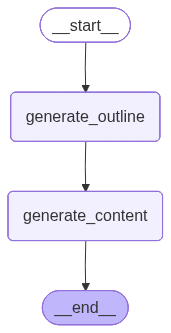

In [9]:
graph = StateGraph(BlogState)

graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_content", generate_content)

graph.add_edge(START, "generate_outline")
graph.add_edge("generate_outline", "generate_content")
graph.add_edge("generate_content", END)

graph.compile()

In [10]:
workflow=graph.compile()
initial_input={"topic": "The Future of AI"}
final_output=workflow.invoke(initial_input)
print(final_output)

{'topic': 'The Future of AI', 'outline': 'Here is a detailed outline for a blog post on "The Future of AI":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its current state\n* Importance of understanding the future of AI in various industries and aspects of life\n* Thesis statement: The future of AI holds immense potential for growth, innovation, and transformation, but also raises concerns about ethics, job displacement, and societal implications.\n\n**II. Advancements in AI Technology**\n\n* Overview of recent advancements in AI, including:\n + Deep learning and neural networks\n + Natural language processing (NLP) and speech recognition\n + Computer vision and image recognition\n + Edge AI and IoT applications\n* Discussion of emerging technologies that are poised to shape the future of AI, such as:\n + Quantum computing\n + Explainable AI (XAI)\n + Transfer learning and domain adaptation\n\n**III. Potential Applications of AI in Various Industries**\

In [11]:
print(final_output["outline"])

Here is a detailed outline for a blog post on "The Future of AI":

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its current state
* Importance of understanding the future of AI in various industries and aspects of life
* Thesis statement: The future of AI holds immense potential for growth, innovation, and transformation, but also raises concerns about ethics, job displacement, and societal implications.

**II. Advancements in AI Technology**

* Overview of recent advancements in AI, including:
 + Deep learning and neural networks
 + Natural language processing (NLP) and speech recognition
 + Computer vision and image recognition
 + Edge AI and IoT applications
* Discussion of emerging technologies that are poised to shape the future of AI, such as:
 + Quantum computing
 + Explainable AI (XAI)
 + Transfer learning and domain adaptation

**III. Potential Applications of AI in Various Industries**

* Healthcare: personalized medicine, diagnosis, and treatment